# Flower-visit detection in PATS-C flight tracks

Reference event used for validation:

| field | value |
|---|---|
| date | 2026-04-13 |
| system | 900 |
| time (UTC) | 11:59:32 - 11:59:38 |
| approach + visit uid | 1002164 |
| departure uid | 1002167 |
| position | (0.170, -1.097, -0.757) |
| visit duration | ~4.4 s |

## Detection signatures

A bumblebee landing on a flower produces one of two patterns in the PATS-C output:

1. **Within-track stationary segment.**  PATS keeps tracking the bee through
   the approach, landing, and visit.  Inside the track there is a contiguous
   stretch of frames where the smoothed position moves less than `disp_thr`
   metres over a `disp_window_s`-second window — that's the visit itself.

2. **Track-A end ≈ track-B start.**  PATS loses the bee mid-visit and picks
   up the departure as a new uid.  Track A's last position is within
   `link_dist` of track B's first position, and B starts somewhere between
   `min_visit_s` and `link_dt_max` after A ends.

Both signatures are detected, then merged: any two candidates within
`2 × link_dist` whose time windows overlap or sit within `link_dt_max` of
each other are collapsed into one visit (handles bees that go back to the
same flower while PATS drops the track once or twice).

Visits within `hive_radius` of the hive are filtered out — those are hive
entries, not flower visits.


In [8]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "font.size": 11})

# ─── tunables ───────────────────────────────────────────────
HIVE_RADIUS_M = 0.3   # ignore visits within this distance of the hive
DISP_WINDOW_S = 1.0    # window for "how far has the bee moved in 1 s?"
DISP_THR_M    = 0.05   # stationary if 1-second displacement < 5 cm
MIN_VISIT_S   = 1.0    # ignore stationary blips shorter than this
LINK_DIST_M   = 0.10   # cross-track pair: same place if within 10 cm
LINK_DT_MAX_S = 30.0   # ...and within this gap between A.end and B.start

# Hive positions per system (from hive_return_results.csv).
HIVE_XYZ = {900: (-0.040, -0.665, -1.195),
            939: (-0.086, -0.828, -1.045)}

# Day to analyse
DAY = "2026-04-13"; SYS = 900
DATA_DIR = Path(f"../../data/{DAY}_system_{SYS}")
print("data dir:", DATA_DIR.resolve())


data dir: /Users/jaspe/Projects/Claude/Bumblebee-monitoring/data/2026-04-13_system_900


In [9]:
def per_track_stationary_segments(ft_sub, disp_window_s, disp_thr, min_visit_s):
    """Stationary segments inside one track."""
    if len(ft_sub) < 30: return []
    times = ft_sub["elapsed"].values
    xs = ft_sub["sposX_insect"].values
    ys = ft_sub["sposY_insect"].values
    zs = ft_sub["sposZ_insect"].values
    disp = np.full(len(ft_sub), np.nan)
    j = 0
    for i in range(len(ft_sub)):
        while j < i and times[i] - times[j] >= disp_window_s:
            j += 1
        ref = max(0, j - 1)
        if i - ref >= 5:
            disp[i] = np.sqrt((xs[i]-xs[ref])**2 + (ys[i]-ys[ref])**2 + (zs[i]-zs[ref])**2)
    stat = (disp < disp_thr) & ~np.isnan(disp)

    out, in_run, rs = [], False, 0
    for i, s in enumerate(stat):
        if s and not in_run: rs = i; in_run = True
        elif not s and in_run:
            t0, t1 = times[rs], times[i-1]
            if t1 - t0 >= min_visit_s:
                out.append((t0, t1, xs[rs:i].mean(), ys[rs:i].mean(), zs[rs:i].mean()))
            in_run = False
    if in_run:
        t0, t1 = times[rs], times[-1]
        if t1 - t0 >= min_visit_s:
            out.append((t0, t1, xs[rs:].mean(), ys[rs:].mean(), zs[rs:].mean()))
    return out


def track_endpoints(ft):
    g = ft.sort_values("elapsed").groupby("detection_uid")
    first = g.first(); last = g.last()
    return pd.DataFrame({
        "uid": first.index,
        "t0": first["elapsed"].values, "t1": last["elapsed"].values,
        "x0": first["sposX_insect"].values, "y0": first["sposY_insect"].values, "z0": first["sposZ_insect"].values,
        "x1": last["sposX_insect"].values,  "y1": last["sposY_insect"].values,  "z1": last["sposZ_insect"].values,
        "n_frames": g.size().values,
    }).reset_index(drop=True)


def detect_visits(ft, hive_xyz,
                  hive_radius=HIVE_RADIUS_M, disp_window_s=DISP_WINDOW_S,
                  disp_thr=DISP_THR_M, min_visit_s=MIN_VISIT_S,
                  link_dist=LINK_DIST_M, link_dt_max=LINK_DT_MAX_S):

    # within-track
    within = []
    for uid, sub in ft.sort_values("elapsed").groupby("detection_uid"):
        for t0, t1, x, y, z in per_track_stationary_segments(sub, disp_window_s, disp_thr, min_visit_s):
            within.append({"source": "within", "t_start": t0, "t_end": t1,
                           "x": x, "y": y, "z": z, "duration_s": t1-t0,
                           "uids": [int(uid)]})

    # cross-track
    endpoints = track_endpoints(ft).sort_values("t1").reset_index(drop=True)
    cross = []
    for _, a in endpoints.iterrows():
        cand = endpoints[(endpoints["t0"] > a["t1"] + min_visit_s) &
                          (endpoints["t0"] < a["t1"] + link_dt_max) &
                          (endpoints["uid"] != a["uid"])]
        if cand.empty: continue
        d = np.sqrt((cand["x0"]-a["x1"])**2 + (cand["y0"]-a["y1"])**2 + (cand["z0"]-a["z1"])**2)
        cand = cand.assign(d=d.values)
        cand = cand[cand["d"] < link_dist]
        if cand.empty: continue
        b = cand.sort_values("t0").iloc[0]
        cross.append({"source": "cross", "t_start": a["t1"], "t_end": b["t0"],
                      "x": 0.5*(a["x1"]+b["x0"]), "y": 0.5*(a["y1"]+b["y0"]), "z": 0.5*(a["z1"]+b["z0"]),
                      "duration_s": b["t0"]-a["t1"],
                      "uids": [int(a["uid"]), int(b["uid"])]})

    visits = within + cross
    if not visits:
        return pd.DataFrame(columns=["source","t_start","t_end","x","y","z","duration_s","uids","dist_hive_m"])
    df = pd.DataFrame(visits)
    hx, hy, hz = hive_xyz
    df["dist_hive_m"] = np.sqrt((df["x"]-hx)**2 + (df["y"]-hy)**2 + (df["z"]-hz)**2)
    df = df[df["dist_hive_m"] > hive_radius].reset_index(drop=True)

    # iterative merge of overlapping visits at the same flower
    merge_dist = link_dist * 2.0
    changed = True
    while changed:
        changed = False
        df = df.sort_values("t_start").reset_index(drop=True)
        keep = np.ones(len(df), dtype=bool)
        for i in range(len(df)):
            if not keep[i]: continue
            for j in range(i+1, len(df)):
                if not keep[j]: continue
                d = np.sqrt((df.iloc[i]["x"]-df.iloc[j]["x"])**2 +
                            (df.iloc[i]["y"]-df.iloc[j]["y"])**2 +
                            (df.iloc[i]["z"]-df.iloc[j]["z"])**2)
                if d >= merge_dist: continue
                overlap = df.iloc[j]["t_start"] <= df.iloc[i]["t_end"]
                gap     = df.iloc[j]["t_start"] - df.iloc[i]["t_end"]
                if overlap or gap < link_dt_max:
                    df.iat[i, df.columns.get_loc("t_start")] = min(df.iloc[i]["t_start"], df.iloc[j]["t_start"])
                    df.iat[i, df.columns.get_loc("t_end")]   = max(df.iloc[i]["t_end"],   df.iloc[j]["t_end"])
                    df.iat[i, df.columns.get_loc("duration_s")] = df.iloc[i]["t_end"] - df.iloc[i]["t_start"]
                    df.iat[i, df.columns.get_loc("x")] = 0.5 * (df.iloc[i]["x"] + df.iloc[j]["x"])
                    df.iat[i, df.columns.get_loc("y")] = 0.5 * (df.iloc[i]["y"] + df.iloc[j]["y"])
                    df.iat[i, df.columns.get_loc("z")] = 0.5 * (df.iloc[i]["z"] + df.iloc[j]["z"])
                    df.iat[i, df.columns.get_loc("uids")] = sorted(set(df.iloc[i]["uids"] + df.iloc[j]["uids"]))
                    df.iat[i, df.columns.get_loc("source")] = "merged"
                    keep[j] = False
                    changed = True
        df = df[keep].reset_index(drop=True)
    return df


## 1. Load data and run the detector


In [10]:
ft  = pd.read_csv(DATA_DIR / "flight_tracks.csv")
det = pd.read_csv(DATA_DIR / "detections.csv")
print(f"flight_tracks: {len(ft):,} frames in {ft['detection_uid'].nunique():,} tracks")
print(f"detections   : {len(det):,}")
print(f"track duration window: {ft['elapsed'].min():.1f} - {ft['elapsed'].max():.1f} s")

visits = detect_visits(ft, HIVE_XYZ[SYS])
print(f"\nDetected {len(visits)} flower visits")
print(f"  within-track: {(visits['source']=='within').sum()}")
print(f"  cross-track : {(visits['source']=='cross').sum()}")
print(f"  merged      : {(visits['source']=='merged').sum()}")


flight_tracks: 81,690 frames in 369 tracks
detections   : 369
track duration window: 11.9 - 3476.8 s

Detected 11 flower visits
  within-track: 6
  cross-track : 4
  merged      : 1


## 2. Validate against the reference


In [11]:
REF_T_RANGE = (1697.89, 1704.67)
REF_POS = (0.170, -1.097, -0.757)
REF_UIDS = [1002164, 1002167]

# find any visit that overlaps the reference time window
hits = visits[(visits["t_start"] <= REF_T_RANGE[1]) & (visits["t_end"] >= REF_T_RANGE[0])]
print(f"=== matches against reference visit (uids {REF_UIDS}) ===")
if hits.empty:
    print("NOT DETECTED  — algorithm failed on the reference")
else:
    for _, r in hits.iterrows():
        d_pos = np.sqrt((r["x"]-REF_POS[0])**2 + (r["y"]-REF_POS[1])**2 + (r["z"]-REF_POS[2])**2)
        ref_match = "REFERENCE UID PRESENT" if any(u in r["uids"] for u in REF_UIDS) else ""
        print(f"  source={r['source']}  t=({r['t_start']:.2f},{r['t_end']:.2f})  "
              f"pos=({r['x']:.3f},{r['y']:.3f},{r['z']:.3f})  "
              f"dur={r['duration_s']:.2f}s  d_to_ref={d_pos*100:.1f}cm  "
              f"uids={r['uids']}  {ref_match}")


=== matches against reference visit (uids [1002164, 1002167]) ===
  source=within  t=(1700.31,1704.67)  pos=(0.170,-1.097,-0.757)  dur=4.36s  d_to_ref=0.0cm  uids=[1002164]  REFERENCE UID PRESENT


## 3. All detected visits (sorted by start time)


In [12]:
# Pretty print all visits with absolute timestamps
t_origin = pd.to_datetime(det["start_datetime"]).min()
def wall_time(elapsed):
    return (t_origin + pd.to_timedelta(elapsed, unit="s")).strftime("%H:%M:%S")

print(f"{'wall_start':>10s}  {'dur':>5s}  {'source':>7s}  "
      f"{'x':>7s}  {'y':>7s}  {'z':>7s}  {'d_hive':>7s}  uids")
for _, r in visits.iterrows():
    print(f"  {wall_time(r['t_start']):>10s}  {r['duration_s']:5.2f}  "
          f"{r['source']:>7s}  {r['x']:7.3f}  {r['y']:7.3f}  {r['z']:7.3f}  "
          f"{r['dist_hive_m']:7.3f}  {r['uids']}")


wall_start    dur   source        x        y        z   d_hive  uids
    11:36:57   4.40    cross    1.114   -1.324   -1.368    1.340  [1002404, 1002409]
    11:41:08   4.91    cross    1.230   -0.611   -1.977    1.492  [1002426, 1002427]
    11:44:05  35.68   merged    0.201   -0.887   -1.170    0.311  [1001784, 1001794, 1002456]
    11:44:33   1.42   within    0.168   -1.092   -0.747    0.653  [1001782]
    11:44:35   3.39    cross   -0.064   -1.063   -0.909    0.491  [1001782, 1001789]
    11:51:21   1.17   within   -1.562   -1.041   -1.509    1.599  [1002548]
    11:55:21   1.35   within   -0.624   -1.229   -0.825    0.892  [1002659]
    11:57:47   1.45   within    0.175   -0.881   -1.138    0.310  [1002685]
    11:59:51   4.36   within    0.170   -1.097   -0.757    0.650  [1002164]
    12:12:44   6.47    cross    1.041   -0.614   -1.097    1.087  [1002845, 1002847]
    12:23:41   2.16   within    0.174   -0.884   -1.138    0.312  [1002919]


## 4. Cluster visits into individual flowers

Visits at near-identical positions are likely the same flower being revisited.
We group by spatial proximity (`CLUSTER_RADIUS_M = 0.15 m`) using greedy
single-link clustering on the 3D position.


In [13]:
CLUSTER_RADIUS_M = 0.15

flower_id = np.full(len(visits), -1, dtype=int)
next_id = 0
for i in range(len(visits)):
    if flower_id[i] != -1: continue
    flower_id[i] = next_id
    # add neighbours
    queue = [i]
    while queue:
        k = queue.pop()
        for j in range(len(visits)):
            if flower_id[j] != -1: continue
            d = np.sqrt((visits.iloc[k]["x"]-visits.iloc[j]["x"])**2 +
                        (visits.iloc[k]["y"]-visits.iloc[j]["y"])**2 +
                        (visits.iloc[k]["z"]-visits.iloc[j]["z"])**2)
            if d < CLUSTER_RADIUS_M:
                flower_id[j] = next_id
                queue.append(j)
    next_id += 1

visits = visits.assign(flower_id=flower_id)

print(f"=== {next_id} distinct flowers visited ===")
flower_summary = (visits.groupby("flower_id")
                        .agg(n_visits=("t_start", "count"),
                             total_visit_s=("duration_s", "sum"),
                             mean_visit_s=("duration_s", "mean"),
                             x=("x","mean"), y=("y","mean"), z=("z","mean"))
                        .sort_values("n_visits", ascending=False))
print(flower_summary.round(3).to_string())


=== 8 distinct flowers visited ===
           n_visits  total_visit_s  mean_visit_s      x      y      z
flower_id                                                            
2                 3         39.282        13.094  0.184 -0.884 -1.148
3                 2          5.787         2.893  0.169 -1.094 -0.752
0                 1          4.396         4.396  1.114 -1.324 -1.368
1                 1          4.907         4.907  1.230 -0.611 -1.977
4                 1          3.394         3.394 -0.064 -1.063 -0.909
5                 1          1.168         1.168 -1.562 -1.041 -1.509
6                 1          1.347         1.347 -0.624 -1.229 -0.825
7                 1          6.465         6.465  1.041 -0.614 -1.097


## 5. Spatial scatter of flower visits


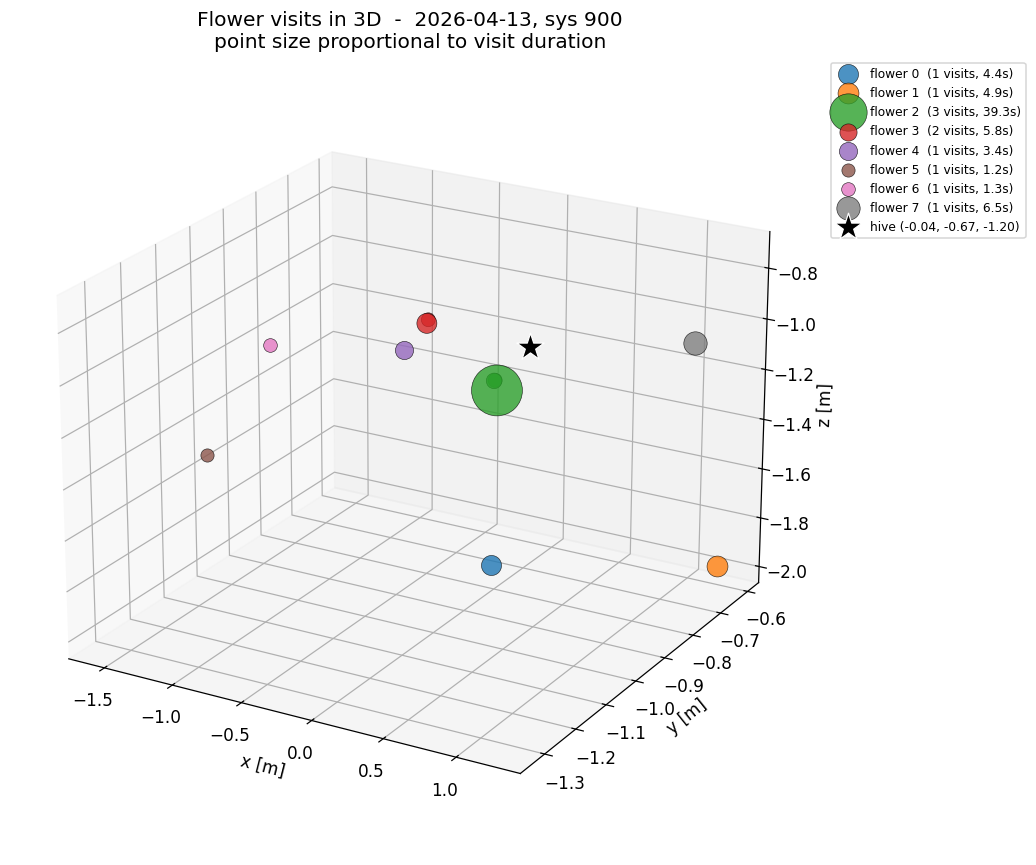

In [14]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 - registers 3D projection

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")

# Plot each flower cluster with a distinct colour, size scaled by visit duration
cmap = plt.get_cmap("tab10")
for fid, sub in visits.groupby("flower_id"):
    ax.scatter(sub["x"], sub["y"], sub["z"],
               s=40 + 30 * sub["duration_s"],
               color=cmap(fid % 10),
               alpha=0.8,
               edgecolor="black",
               linewidth=0.4,
               label=f"flower {fid}  ({len(sub)} visits, {sub['duration_s'].sum():.1f}s)")

# Hive marker
hx, hy, hz = HIVE_XYZ[SYS]
ax.scatter([hx], [hy], [hz],
           marker="*", s=350, c="black", edgecolor="white", linewidth=0.8,
           label=f"hive ({hx:.2f}, {hy:.2f}, {hz:.2f})")

ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_zlabel("z [m]")
ax.set_title(f"Flower visits in 3D  -  {DAY}, sys {SYS}\n"
             f"point size proportional to visit duration")
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.02, 1.0))

# Set viewing angle - greenhouse layout reads best with a slight tilt
ax.view_init(elev=22, azim=-60)

plt.tight_layout(); plt.show()


## 6. Distribution of visit durations


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(visits["duration_s"], bins=np.linspace(0, max(40, visits["duration_s"].max()+1), 20),
        color="#5B8FD4", edgecolor="black")
ax.set_xlabel("visit duration (s)"); ax.set_ylabel("count")
ax.set_title(f"Visit duration distribution  -  {DAY}, sys {SYS}")
plt.tight_layout(); plt.show()

print(f"\nVisit duration stats (s):")
print(visits["duration_s"].describe().round(2).to_string())


## 7. How to extend this

**Run on all exposure days.**  Wrap the loader + detector in a loop over the
`data/<date>_system_<sys>/` directories and concatenate the visits.  Output
schema (one row per visit):

```
date, system_id, t_start, t_end, x, y, z, duration_s, flower_id, source, uids
```

This becomes a new indicator stream usable in `5g_foraging_effect_model.ipynb`:

- **n_flower_visits / day**  — total foraging effort
- **mean_visit_duration**    — handling time per flower (a classical foraging metric)
- **n_distinct_flowers**     — how many separate flowers the colony exploited
- **revisit_rate**           — visits per flower (efficient foragers revisit good flowers)

**Tune the tunables.**  If the detector misses obvious visits or fires on
clear non-visits, the four knobs that matter most are:

| knob | what it controls |
|---|---|
| `DISP_THR_M` | how still the bee has to be to count as "on flower" |
| `MIN_VISIT_S` | minimum visit duration kept |
| `LINK_DIST_M` | how close cross-track endpoints have to be |
| `HIVE_RADIUS_M` | how aggressively we cut hive entries |

**Cross-validate with hive_exit_v3.**  Real foraging trips should have:
hive exit → ≥ 1 flower visit → hive return.  Counting trips that do/do not
contain at least one detected flower visit gives a quality metric for the
detector.
